# Tatoeba: N-Gram Hashing

Author: Pierre Nugues

In this notbook, we will reduce the size of the n-gram vectors using hashing techniques

This is a preliminary step to understand language detection and CLD3, https://github.com/google/cld3

In [1]:
import random
from collections import Counter
import torch
import matplotlib.pyplot as plt

In [2]:
random.seed(4321)
torch.manual_seed(4321)

## Reading the Dataset

In [3]:
FILE = 'sentences.csv'

Adjust your path

In [4]:
SMALL_DATASET_PATH = '.'
LARGE_DATASET_PATH = '.'

In [5]:
SMALL = False

In [6]:
if SMALL:
    dataset_path = SMALL_DATASET_PATH
else:
    dataset_path = LARGE_DATASET_PATH
    
WORKING_FILE = dataset_path + '/' + FILE

We create a generator

In [7]:
def file_reader(file):
    with open(file, encoding='utf8', errors='ignore') as f:
        for line in f:
            row = line.strip()
            yield tuple(row.split('\t'))

In [8]:
line_generator = file_reader(WORKING_FILE)

And we count the sentences per language

In [9]:
lang_freqs = Counter(map(lambda x: x[1], line_generator))

In [10]:
lang_freqs.most_common(15)

[('eng', 2037522),
 ('rus', 1226604),
 ('ita', 988069),
 ('epo', 822067),
 ('kab', 792672),
 ('deu', 781916),
 ('tur', 749267),
 ('fra', 727168),
 ('ber', 693766),
 ('por', 444884),
 ('spa', 442260),
 ('hun', 441185),
 ('jpn', 248917),
 ('heb', 212700),
 ('nld', 201207)]

In [11]:
langs = sorted(list(set(lang_freqs.keys())))
langs[:10]

['\\N', 'abk', 'abq', 'acm', 'ady', 'afb', 'afh', 'afr', 'aii', 'ain']

## Extracting n-grams

In [12]:
def ngrams(sentence, n=1, lc=True):
    ngram_l = []
    if lc:
        sentence = sentence.lower()
    for i in range(len(sentence) - n + 1):
        ngram_l += [sentence[i:i+n]]
    return ngram_l

In [13]:
def all_ngrams(sentence, max_ngram=3, lc=True):
    all_ngram_list = []
    for i in range(1, max_ngram + 1):
        all_ngram_list += [ngrams(sentence, n=i, lc=lc)]
    return all_ngram_list

In [14]:
all_ngrams('banana')

[['b', 'a', 'n', 'a', 'n', 'a'],
 ['ba', 'an', 'na', 'an', 'na'],
 ['ban', 'ana', 'nan', 'ana']]

## Extracting n-grams from the corpus

In [15]:
def extract_ngrams():
    with open(WORKING_FILE, encoding='utf8', errors='ignore') as f:
        for line in f:
            row = line.strip()
            lang_tuple = tuple(row.split('\t'))
            lang = lang_tuple[1]
            if lang in langs:
                yield all_ngrams(lang_tuple[2])       

We assume three, otherwise we have to create a list

In [16]:
charset = set()
bigram_set = set()
trigram_set = set()

In [17]:
for triple in extract_ngrams():
    charset.update(triple[0])
    bigram_set.update(triple[1])
    trigram_set.update(triple[2])


In [18]:
len(charset), len(bigram_set), len(trigram_set)

(11728, 548380, 2362711)

## Hashing the n-grams and limiting their numbers

In [20]:
hash('ads'), hash('ads') % 100

(-7525077169729061972, 28)

In [21]:
if SMALL:
    MAX_CHARS = 521
    MAX_BIGRAMS = 1031
    MAX_TRIGRAMS = 1031  
else:
    MAX_CHARS = 2053
    MAX_BIGRAMS = 4099
    MAX_TRIGRAMS = 4099  #8192

In [22]:
NUM_FEATURES = MAX_CHARS + MAX_BIGRAMS + MAX_TRIGRAMS
NUM_FEATURES

10251

In [23]:
def hash_conflicts(symbol_set, modulo):
    conflict_dict = dict()
    for symb in symbol_set:
        hash_code = hash(symb) % modulo
        if hash_code in conflict_dict:
            conflict_dict[hash_code] += [symb]
        else:
            conflict_dict[hash_code] = [symb]
    return conflict_dict

In [24]:
hash_conflicts_1 = hash_conflicts(charset, MAX_CHARS)
hash_conflicts_2 = hash_conflicts(bigram_set, MAX_BIGRAMS)
hash_conflicts_3 = hash_conflicts(trigram_set, MAX_TRIGRAMS)

In [25]:
hash('a') % 2053

1776

In [28]:
hash_conflicts_1[1776]

['a', 'ታ', '𤞚', '迦', 'ѐ', '沉', '蔼']

In [27]:
hash('abc') % 4099

402

In [31]:
hash_conflicts_3[402]

['啲嘢做',
 'لgp',
 'öp!',
 '財物，',
 '个周立',
 '他自信',
 'aḍr',
 '一位会',
 '女は戸',
 'て、事',
 '人林賽',
 '们身体',
 '趣？佢',
 'つも青',
 '持ちこ',
 '亞當講',
 'ラが回',
 ' آد',
 '琴又会',
 '嗰啲活',
 'もつべ',
 '，越来',
 '. ഒ',
 'hq ',
 'wük',
 '福斯林',
 '紙でな',
 '爭嚟破',
 '要引擎',
 'ኸዲኑ',
 '部はと',
 '。 f',
 '射擊不',
 'ⵓⵥ.',
 '宙入面',
 '气温突',
 'いをこ',
 '座は空',
 '一段特',
 '沙士可',
 '전공이',
 'に海藻',
 'ち、パ',
 '主角；',
 '沿住條',
 'こで道',
 '君が前',
 'al』',
 '變得靠',
 'рык',
 '𑣕𑣃𑣔',
 'ꦼꦥꦺ',
 'قكۆ',
 '下箇星',
 '文不難',
 'ν π',
 '你也會',
 '一个天',
 'ຄັນ',
 '一で約',
 '齊呀？',
 'り替わ',
 '、カゼ',
 '紙でプ',
 '自塔什',
 'ltü',
 '我想發',
 '吸煙了',
 'วิต',
 '是例行',
 '華，去',
 'ནས་',
 'いの人',
 '係將個',
 'ዎ፥ ',
 '票每人',
 '力行,',
 '政典》',
 '冠更加',
 '水在陽',
 '架車幾',
 ' ምጕ',
 '小猫ち',
 '膊頭一',
 '産は相',
 'ldi',
 '近其中',
 '囉。」',
 '起，上',
 'ば、口',
 '前端嘅',
 '好嘅結',
 '夢，臥',
 '化学を',
 '星嘅決',
 'だ心身',
 'ዲና፣',
 'ாலய',
 '遭受到',
 '立刻漫',
 'が席外',
 'った母',
 '株主は',
 '，人應',
 '策略。',
 '修工事',
 '種『魔',
 'q ٹ',
 'ܫܥܳ',
 '事同男',
 '喜欢苹',
 '个有预',
 'ỏa?',
 '但卻發',
 '私が機',
 'ійм',
 '무기이',
 'と、姉',
 '塵機去',
 '巴西身',
 'もたげ',
 '色列政',
 '量の荷',
 'ôtc',
 '間。根',


In [32]:
len(hash_conflicts_3[402])

611

Expected number of symbols per hash code

In [33]:
len(charset)/MAX_CHARS, len(bigram_set)/MAX_BIGRAMS, len(trigram_set)/MAX_TRIGRAMS

(5.712615684364345, 133.78384971944377, 576.4115637960479)

Observed frequencies

In [34]:
cnt_hc_1 = Counter(map(len, hash_conflicts_1.values()))
cnt_hc_1

Counter({5: 360,
         6: 311,
         4: 294,
         7: 269,
         3: 208,
         8: 199,
         9: 125,
         2: 100,
         10: 75,
         1: 48,
         11: 28,
         12: 16,
         13: 7,
         14: 4,
         17: 1})

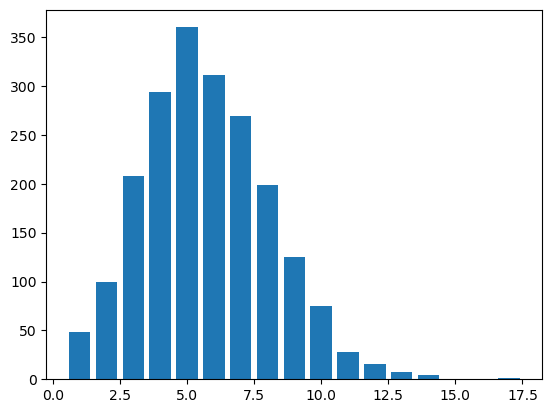

In [35]:
plt.bar(cnt_hc_1.keys(), cnt_hc_1.values())
plt.show()

In [36]:
cnt_hc_2= Counter(map(len, hash_conflicts_2.values()))
cnt_hc_2

Counter({135: 152,
         130: 152,
         132: 145,
         138: 143,
         128: 140,
         129: 138,
         137: 133,
         134: 132,
         131: 127,
         141: 125,
         133: 125,
         127: 124,
         136: 122,
         139: 115,
         140: 115,
         126: 112,
         143: 108,
         142: 106,
         145: 105,
         124: 103,
         125: 102,
         123: 92,
         144: 83,
         121: 80,
         122: 79,
         148: 79,
         146: 78,
         120: 72,
         119: 69,
         147: 65,
         118: 53,
         149: 49,
         151: 49,
         150: 49,
         115: 46,
         152: 42,
         117: 42,
         113: 38,
         114: 35,
         154: 33,
         116: 32,
         156: 32,
         155: 31,
         153: 29,
         112: 24,
         111: 24,
         157: 21,
         110: 20,
         159: 14,
         162: 13,
         158: 12,
         109: 11,
         108: 11,
         161: 10,
       

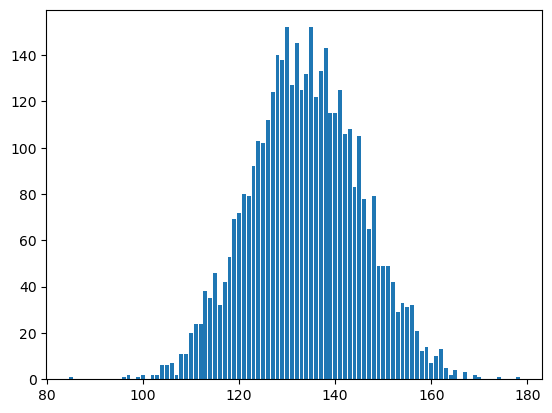

In [37]:
plt.bar(cnt_hc_2.keys(), cnt_hc_2.values())
plt.show()

In [38]:
cnt_hc_3 = Counter(map(len, hash_conflicts_3.values()))

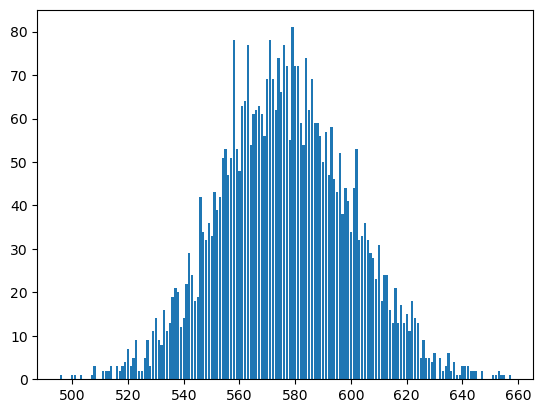

In [39]:
plt.bar(cnt_hc_3.keys(), cnt_hc_3.values())
plt.show()